Total records: 4163
Anomalies: 416 (10.0%)
anomaly_type
duplicate_vendor      104
cost_overrun          104
delayed_completion    104
sanction_delay        104
Name: count, dtype: int64
Max sanctioned_amount: ₹200,000,000


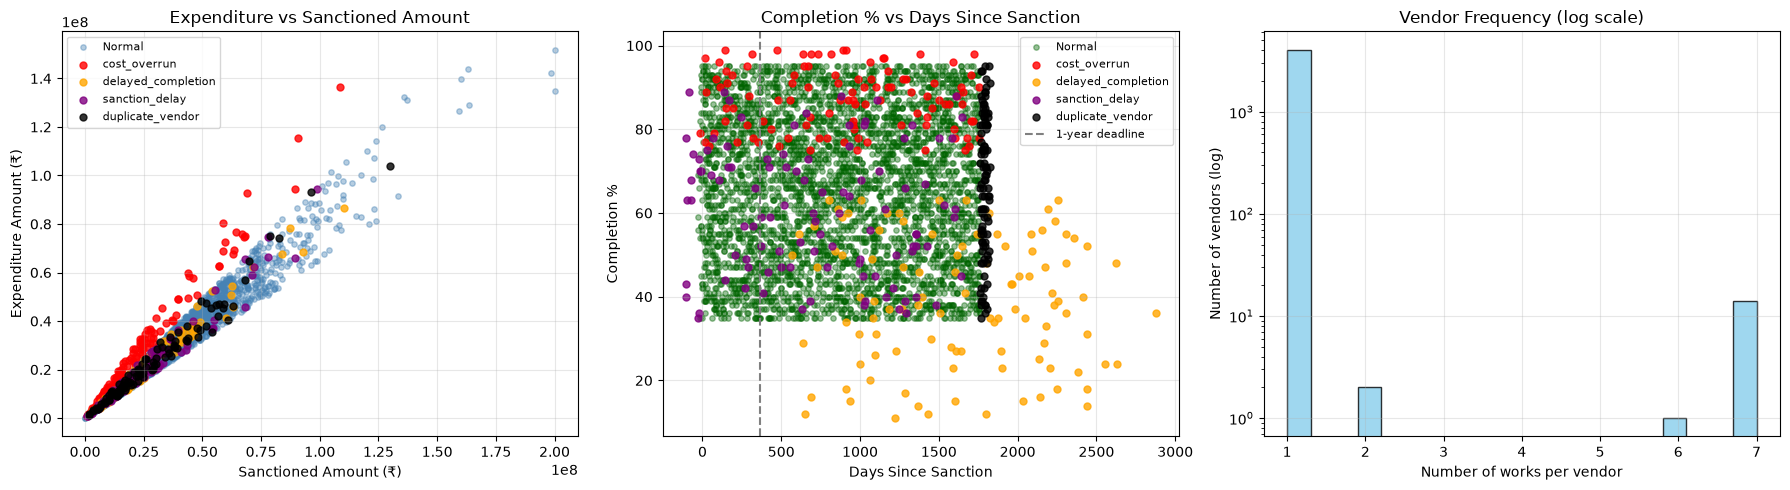


Top 10 vendors by work count:
vendor_id
V-DUP-001    7
V-DUP-000    7
V-DUP-004    7
V-DUP-005    7
V-DUP-008    7
V-DUP-012    7
V-DUP-010    7
V-DUP-003    7
V-DUP-009    7
V-DUP-011    7
Name: count, dtype: int64


: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("../data/processed/works.csv")

for col in ["sanctioned_amount", "expenditure_amount", "completion_percent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["recommended_date", "sanction_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["is_anomaly"] = df["is_anomaly"].fillna(False).astype(bool)
df["days_since_sanction"] = (pd.Timestamp.now().normalize() - df["sanction_date"]).dt.days

print(f"Total records: {len(df)}")
print(f"Anomalies: {df['is_anomaly'].sum()} ({df['is_anomaly'].mean()*100:.1f}%)")
print(df["anomaly_type"].value_counts())
print(f"Max sanctioned_amount: ₹{df['sanctioned_amount'].max():,.0f}")

colors = {"cost_overrun": "red", "delayed_completion": "orange",
          "sanction_delay": "purple", "duplicate_vendor": "black"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

normal = df[~df["is_anomaly"]]
axes[0].scatter(normal["sanctioned_amount"], normal["expenditure_amount"],
                 color="steelblue", alpha=0.4, s=15, label="Normal")
for atype, color in colors.items():
    subset = df[df["anomaly_type"] == atype]
    axes[0].scatter(subset["sanctioned_amount"], subset["expenditure_amount"],
                     color=color, alpha=0.8, s=25, label=atype)
axes[0].set_title("Expenditure vs Sanctioned Amount")
axes[0].set_xlabel("Sanctioned Amount (₹)")
axes[0].set_ylabel("Expenditure Amount (₹)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].scatter(normal["days_since_sanction"], normal["completion_percent"],
                 color="darkgreen", alpha=0.4, s=15, label="Normal")
for atype, color in colors.items():
    subset = df[df["anomaly_type"] == atype]
    axes[1].scatter(subset["days_since_sanction"], subset["completion_percent"],
                     color=color, alpha=0.8, s=25, label=atype)
axes[1].axvline(365, color="gray", linestyle="--", label="1-year deadline")
axes[1].set_title("Completion % vs Days Since Sanction")
axes[1].set_xlabel("Days Since Sanction")
axes[1].set_ylabel("Completion %")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

vendor_counts = df["vendor_id"].value_counts()
axes[2].hist(vendor_counts.values, bins=20, color="skyblue", edgecolor="black", alpha=0.8)
axes[2].set_yscale("log")
axes[2].set_title("Vendor Frequency (log scale)")
axes[2].set_xlabel("Number of works per vendor")
axes[2].set_ylabel("Number of vendors (log)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/eda_summary.png", dpi=150)
plt.show()

print("\nTop 10 vendors by work count:")
print(vendor_counts.head(10))

In [6]:
import pandas as pd

# Load the generated works data
df = pd.read_csv("../data/processed/works.csv")

# Load the real MP allocation data from the raw Lok Sabha and Rajya Sabha files
lok = pd.read_csv("../data/raw/Lok_sabha.csv")
raj = pd.read_csv("../data/raw/Rajya_sabha.csv")
allocations = pd.concat([lok, raj], ignore_index=True)

# Normalize columns
allocations.columns = [str(c).strip() for c in allocations.columns]
allocations = allocations.rename(columns={
    "Hon'ble Members of Parliaments": "mp_name",
    "Allocated AMOUNT ( ₹ )": "Allocated AMOUNT ( ₹ )"
})

# Remove any non-data rows safely, regardless of whether "Sr. No." is string or numeric
allocations = allocations[pd.to_numeric(allocations["Sr. No."], errors="coerce").notna()].copy()

# Clean amount values
allocations["Allocated AMOUNT ( ₹ )"] = pd.to_numeric(
    allocations["Allocated AMOUNT ( ₹ )"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

# Clean the works dataframe
df["sanctioned_amount"] = pd.to_numeric(df["sanctioned_amount"], errors="coerce")
df["expenditure_amount"] = pd.to_numeric(df["expenditure_amount"], errors="coerce")
df["is_anomaly"] = df["is_anomaly"].fillna(False).astype(bool)
df["anomaly_type"] = df["anomaly_type"].fillna("normal")

# 1) Cap check — no MP's total sanctioned amount should exceed their real allocation
mp_totals = df.groupby("mp_name")["sanctioned_amount"].sum().reset_index()
merged = mp_totals.merge(
    allocations[["mp_name", "Allocated AMOUNT ( ₹ )"]],
    on="mp_name",
    how="left"
)
violations = merged[merged["sanctioned_amount"] > merged["Allocated AMOUNT ( ₹ )"]]
print(f"MPs exceeding their allocation cap: {len(violations)}")
if len(violations) > 0:
    print(violations[["mp_name", "sanctioned_amount", "Allocated AMOUNT ( ₹ )"]].head())

# 2) Anomaly type balance check
print("\nAnomaly type distribution:")
print(df["anomaly_type"].value_counts())
print(f"\nTotal anomaly %: {df['is_anomaly'].mean()*100:.1f}%")

# 3) Cost overrun ratio check — should be 1.05x-1.4x, not wild outliers
overruns = df[df["anomaly_type"] == "cost_overrun"]
ratio = overruns["expenditure_amount"] / overruns["sanctioned_amount"]
print(f"\ncost_overrun ratio range: {ratio.min():.2f} - {ratio.max():.2f} (should be ~1.05-1.4)")

# 4) Max sanctioned_amount sanity check — should be well under ₹19 crore range
print(f"\nMax sanctioned_amount: ₹{df['sanctioned_amount'].max():,.0f}")

MPs exceeding their allocation cap: 1
                               mp_name  sanctioned_amount  \
317  MOHITE PATIL DHAIRYASHEEL RAJSINH        195613601.7   

     Allocated AMOUNT ( ₹ )  
317             195613601.7  

Anomaly type distribution:
anomaly_type
normal                3757
cost_overrun           105
delayed_completion     105
duplicate_vendor       104
sanction_delay         104
Name: count, dtype: int64

Total anomaly %: 10.0%

cost_overrun ratio range: 1.05 - 1.39 (should be ~1.05-1.4)

Max sanctioned_amount: ₹47,257,744,005
